
# Self-Attention & variants

**Goal:** Complete the TODOs to implement and understand self-attention and variants.  
**Device:** GPU (CUDA) if available, else CPU.  
**Visuals:** Heatmaps use fixed color scales for fair comparisons.


### 0) Setup & device

In [52]:

import math, time, numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def get_device():
    if torch.cuda.is_available():
        return torch.device('cuda')
    # if torch.backends.mps.is_available():
    #     return torch.device('mps')
    return torch.device('cpu')

device = get_device()
torch.manual_seed(0)
np.random.seed(0)
print("Using device:", device)


Using device: cuda


### 1) Helpers (stable softmax & fixed-scale heatmap)

In [53]:

def softmax_stable(x, dim=-1):
    """TODO: Implement numerically stable softmax.
Hint: subtract x.max(dim, keepdim=True).values before exp."""
    x_max = x.max(dim=dim, keepdim=True).values
    e_x = torch.exp(x - x_max)
    return e_x / e_x.sum(dim=dim, keepdim=True)

def show_attention(A, xticks=None, yticks=None, title="Attention", vmin=None, vmax=None):
    fig = plt.figure(figsize=(5,4))
    import numpy as np
    A_np = A.detach().cpu().numpy() if torch.is_tensor(A) else np.array(A)
    plt.imshow(A_np, aspect='auto', vmin=vmin, vmax=vmax)
    if xticks is not None:
        plt.xticks(range(len(xticks)), xticks, rotation=45, ha='right')
    if yticks is not None:
        plt.yticks(range(len(yticks)), yticks)
    plt.title(title); plt.colorbar(); plt.tight_layout(); plt.show()


In [54]:

# TEST
x = torch.randn(4,5)
p = softmax_stable(x, dim=-1)
assert p.shape == (4,5)
assert torch.allclose(p.sum(-1), torch.ones(4), atol=1e-6)
print("✓ softmax_stable basic test passed")


✓ softmax_stable basic test passed


### 2) Single-head Self-Attention (tiny numeric example)

In [55]:

L = 3; d_model = 4; d_k = d_v = 2
X = torch.tensor([[1.,0.,1.,0.],
                  [0.,1.,1.,0.],
                  [0.,0.,1.,1.]], device=device)
WQ = torch.tensor([[1.,0.],[0.,1.],[1.,0.],[0.,1.]], device=device)
WK = torch.tensor([[1.,1.],[0.,1.],[1.,0.],[0.,1.]], device=device)
WV = torch.tensor([[0.,1.],[1.,0.],[1.,1.],[0.,1.]], device=device)

# TODO: compute Q, K, V, scores (scaled), A (= softmax), and out (= A @ V)
Q = X @ WQ  # (L, d_k)
K = X @ WK  # (L, d_k)
V = X @ WV  # (L, d_v)

scores = Q @ K.T / math.sqrt(d_k)  # (L, L)
A = softmax_stable(scores, dim=-1)  # (L, L)
out = A @ V  # (L, d_v)

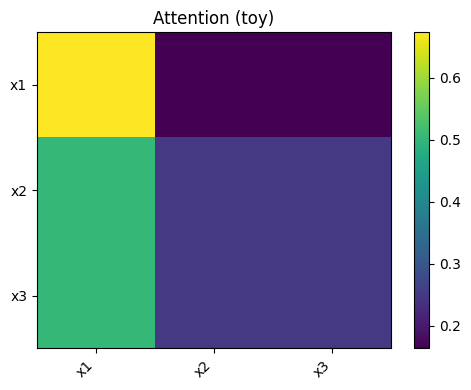

✓ Single-head toy attention passed


In [56]:

# TESTS
assert Q.shape == (L, d_k) and K.shape == (L, d_k) and V.shape == (L, d_v)
assert scores.shape == (L, L) and A.shape == (L, L) and out.shape == (L, d_v)
assert torch.allclose(A.sum(-1), torch.ones(L, device=device), atol=1e-6)
show_attention(A, xticks=["x1","x2","x3"], yticks=["x1","x2","x3"], title="Attention (toy)")
print("✓ Single-head toy attention passed")


### 3) Effect of removing the scale (1/sqrt(d_k))

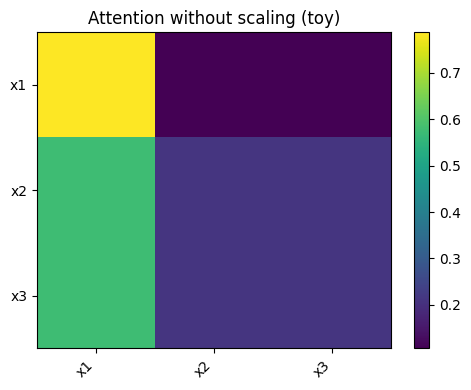

In [57]:

def row_entropy(p, dim=-1):
    """TODO: Shannon entropy per row (natural log). Clamp p before log."""
    p_clamped = torch.clamp(p, min=1e-12)
    return -torch.sum(p_clamped * torch.log(p_clamped), dim=dim)

# TODO: A_noscale, vmin/vmax, plots, and print mean entropies
A_noscale = softmax_stable(Q @ K.T, dim=-1)
vmin = min(A.min().item(), A_noscale.min().item())
vmax = max(A.max().item(), A_noscale.max().item())
show_attention(A_noscale, xticks=["x1","x2","x3"], yticks=["x1","x2","x3"],
               title="Attention without scaling (toy)", vmin=vmin, vmax=vmax)


### 4) Scaled Dot-Product Attention

In [58]:

def scaled_dot_product_attention(Q, K, V, mask=None):
    """TODO: Implement batched attention.
Q:[B,Lq,d_k], K:[B,Lk,d_k], V:[B,Lk,d_v], mask:[B,Lq,Lk] or [B,1,Lq,Lk]"""
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)  # (B, Lq, Lk)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float('-inf'))
    A = softmax_stable(scores, dim=-1)  # (B, Lq, Lk)
    out = A @ V  # (B, Lq, d_v)
    return out, A


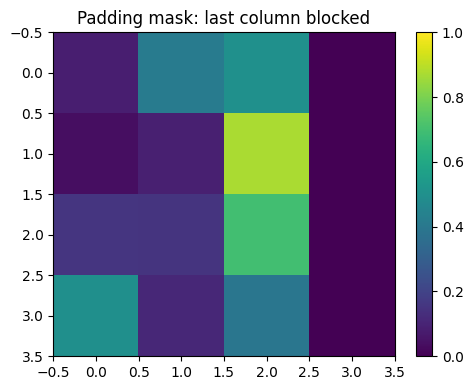

✓ Scaled dot-product attention (batched) passed


In [59]:
# TESTS — padding mask
B, Lq, Lk, dk, dv = 1, 4, 4, 8, 8
Qb = torch.randn(B, Lq, dk, device=device)
Kb = torch.randn(B, Lk, dk, device=device)
Vb = torch.randn(B, Lk, dv, device=device)
mask_pad = torch.ones(B, Lq, Lk, device=device); mask_pad[:, :, -1] = 0
out_pad, A_pad = scaled_dot_product_attention(Qb, Kb, Vb, mask=mask_pad)
assert out_pad.shape == (B,Lq,dv) and A_pad.shape == (B,Lq,Lk)
assert torch.allclose(A_pad[0,:, -1], torch.zeros(Lq, device=device), atol=1e-6)
show_attention(A_pad[0], title="Padding mask: last column blocked", vmin=0.0, vmax=1.0)
print("✓ Scaled dot-product attention (batched) passed")

### 5) Causal (Look-ahead) Mask — 3D

In [60]:

# TODO: build 3D causal mask and apply attention; then test that future positions are zeroed
def subsequent_mask(size):
    """Create a causal mask for attention of shape (1, size, size)."""
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape, device=device), diagonal=1).bool()
    return ~subsequent_mask  # Invert to have True where allowed


### 6) Multi-Head Self-Attention (MHSA)

In [61]:

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model=64, num_heads=8, d_v=None, bias=False):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = self.d_k if d_v is None else d_v
        self.WQ = nn.Linear(d_model, num_heads*self.d_k, bias=bias)
        self.WK = nn.Linear(d_model, num_heads*self.d_k, bias=bias)
        self.WV = nn.Linear(d_model, num_heads*self.d_v, bias=bias)
        self.WO = nn.Linear(num_heads*self.d_v, d_model, bias=bias)

    def forward(self, X, mask=None):  # mask [B,L,L] or None
        # TODO: implement MHSA forward
        B, L, _ = X.size()
        Q = self.WQ(X).view(B, L, self.num_heads, self.d_k).transpose(1,2)  # (B, h, L, d_k)
        K = self.WK(X).view(B, L, self.num_heads, self.d_k).transpose(1,2)  # (B, h, L, d_k)
        V = self.WV(X).view(B, L, self.num_heads, self.d_v).transpose(1,2)  # (B, h, L, d_v)
        if mask is not None:
            mask = mask.unsqueeze(1)  # (B, 1, L, L)
        out, A = scaled_dot_product_attention(Q.reshape(B*self.num_heads, L, self.d_k),
                                             K.reshape(B*self.num_heads, L, self.d_k),
                                             V.reshape(B*self.num_heads, L, self.d_v),
                                             mask=mask.repeat_interleave(self.num_heads, dim=0) if mask is not None else None)
        out = out.view(B, self.num_heads, L, self.d_v).transpose(1,2).reshape(B, L, self.num_heads*self.d_v)  # (B, L, h*d_v)
        out = self.WO(out)  # (B, L, d_model)
        return out, A.view(B, self.num_heads, L, L)


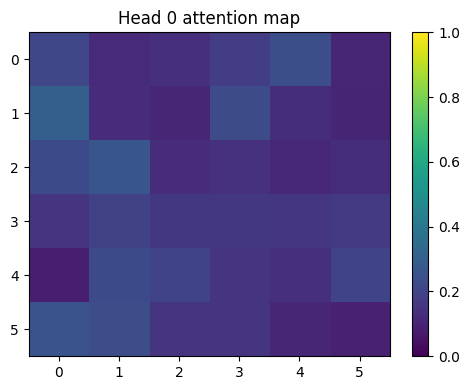

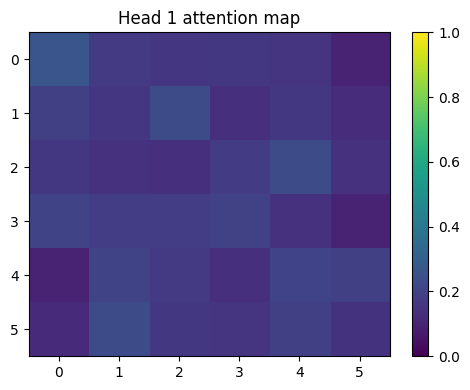

✓ MHSA forward basic test passed


In [62]:

# TESTS — run MHSA and plot two heads
B, L, d_model, H = 1, 6, 64, 2
X_demo = torch.randn(B, L, d_model, device=device)
mhsa = MultiHeadSelfAttention(d_model, H).to(device)
Z, A_heads = mhsa(X_demo)
assert Z.shape == (B,L,d_model) and A_heads.shape == (B,H,L,L)
show_attention(A_heads[0,0], title="Head 0 attention map", vmin=0.0, vmax=1.0)
show_attention(A_heads[0,1], title="Head 1 attention map", vmin=0.0, vmax=1.0)
print("✓ MHSA forward basic test passed")


### 7) Positional encodings (sinusoidal & learned)

In [63]:

def sinusoidal_pe(L, d_model, device):
    """TODO: Return [L, d_model] sinusoidal PE (Vaswani et al.)."""
    pe = torch.zeros(L, d_model, device=device)
    position = torch.arange(0, L, dtype=torch.float, device=device).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float, device=device) *
                         -(math.log(10000.0) / d_model))
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe

class LearnedPE(nn.Module):
    def __init__(self, max_len, d_model, device=None):
        super().__init__()
        self.emb = nn.Embedding(max_len, d_model)
        if device is not None:
            self.to(device)
    def forward(self, L):
        """TODO: return positional embeddings for positions [0..L-1] on same device as emb."""
        positions = torch.arange(L, device=self.emb.weight.device)
        return self.emb(positions)


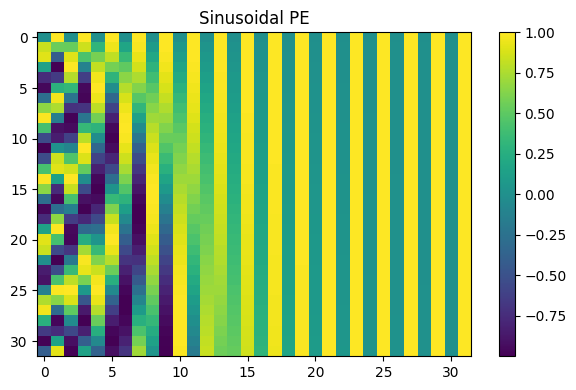

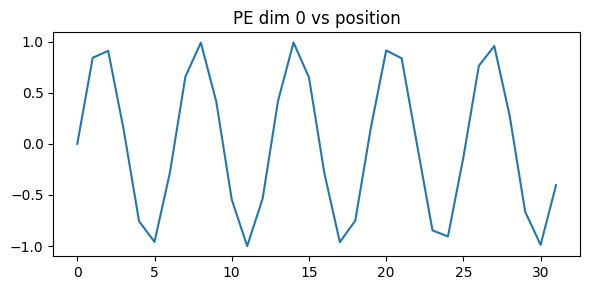

✓ Positional encodings basic tests passed


In [64]:

# TESTS — visualize sinusoidal PE and ensure shapes
L = 32; d_model = 32
pe = sinusoidal_pe(L, d_model, device=device)
assert pe.shape == (L,d_model)
fig = plt.figure(figsize=(6,4)); plt.imshow(pe.detach().cpu().numpy(), aspect='auto'); plt.title("Sinusoidal PE"); plt.colorbar(); plt.tight_layout(); plt.show()
fig = plt.figure(figsize=(6,3)); plt.plot(pe[:,0].detach().cpu().numpy()); plt.title("PE dim 0 vs position"); plt.tight_layout(); plt.show()

learned = LearnedPE(64, d_model, device=device)
pe_learned = learned(L)
assert pe_learned.shape == (L, d_model)
print("✓ Positional encodings basic tests passed")


### 8) Effect of positional information on attention

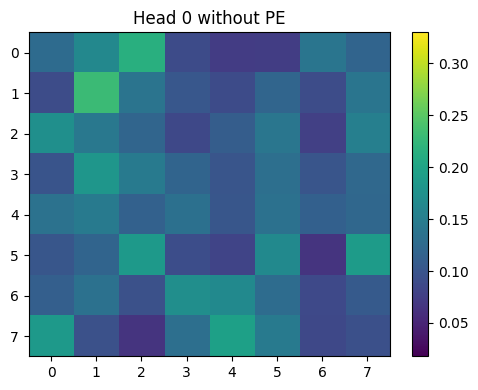

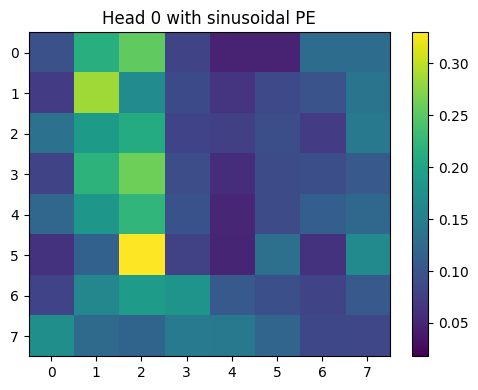

✓ Effect of PE: visual comparison done


In [65]:

B, L, d_model, H = 1, 8, 64, 2
X = torch.randn(B, L, d_model, device=device)
mhsa = MultiHeadSelfAttention(d_model, H).to(device)

Z0, A0 = mhsa(X)  # without PE
PE = sinusoidal_pe(L, d_model, device=device).unsqueeze(0)
Z1, A1 = mhsa(X + PE)  # with PE

vmin = torch.min(torch.stack([A0.min(), A1.min()])).item()
vmax = torch.max(torch.stack([A0.max(), A1.max()])).item()
show_attention(A0[0,0], title="Head 0 without PE", vmin=vmin, vmax=vmax)
show_attention(A1[0,0], title="Head 0 with sinusoidal PE", vmin=vmin, vmax=vmax)
print("✓ Effect of PE: visual comparison done")


### 9) RoPE (toy) on Q/K

In [66]:

def apply_toy_rope(Q, K):
    """TODO: Q,K: [B,H,L,d] with even d. Return rotated versions (toy RoPE)."""
    d = Q.size(-1)
    Q_even = Q[..., 0::2]
    Q_odd = Q[..., 1::2]
    K_even = K[..., 0::2]
    K_odd = K[..., 1::2]
    Q_rotated = torch.zeros_like(Q)
    K_rotated = torch.zeros_like(K)
    Q_rotated[..., 0::2] = Q_even * 0.0 - Q_odd * 1.0
    Q_rotated[..., 1::2] = Q_even * 1.0 + Q_odd * 0.0
    K_rotated[..., 0::2] = K_even * 0.0 - K_odd * 1.0
    K_rotated[..., 1::2] = K_even * 1.0 + K_odd * 0.0
    return Q_rotated, K_rotated


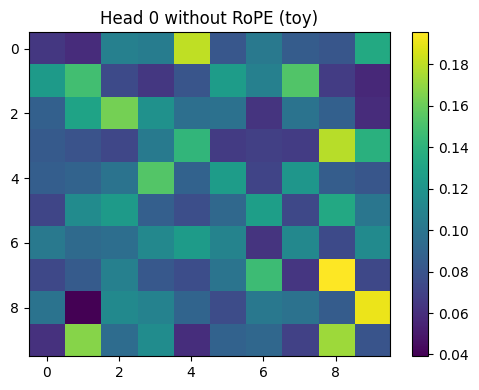

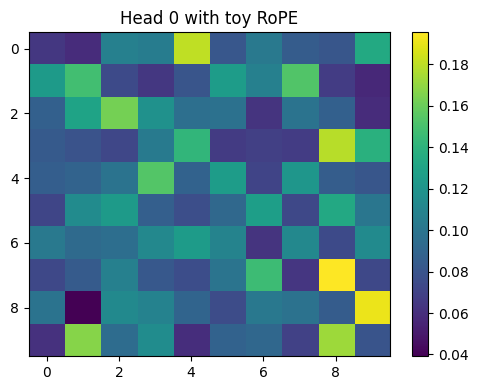

✓ Toy RoPE comparison plotted


In [67]:

# TESTS — compare attention with/without toy RoPE
B,L,d_model,H = 1, 10, 64, 2
X = torch.randn(B, L, d_model, device=device)
mhsa = MultiHeadSelfAttention(d_model, H).to(device)
with torch.no_grad():
    Q = mhsa.WQ(X).view(B,L,H,mhsa.d_k).transpose(1,2)
    K = mhsa.WK(X).view(B,L,H,mhsa.d_k).transpose(1,2)

Q_r, K_r = apply_toy_rope(Q, K)
scores_plain = Q @ K.transpose(-2,-1) / math.sqrt(mhsa.d_k)
scores_rope  = Q_r @ K_r.transpose(-2,-1) / math.sqrt(mhsa.d_k)
A_plain = softmax_stable(scores_plain, dim=-1)[0,0]
A_rope  = softmax_stable(scores_rope,  dim=-1)[0,0]
vmin = torch.min(torch.stack([A_plain.min(), A_rope.min()])).item()
vmax = torch.max(torch.stack([A_plain.max(), A_rope.max()])).item()
show_attention(A_plain, title="Head 0 without RoPE (toy)", vmin=vmin, vmax=vmax)
show_attention(A_rope,  title="Head 0 with toy RoPE",     vmin=vmin, vmax=vmax)
print("✓ Toy RoPE comparison plotted")


### 10) ALiBi-like Linear Biases

In [68]:

def alibi_slopes(n_heads):
    """TODO: return slopes per head (e.g., [1, 1/2, 1/4, ...])."""
    return [1 / (2 ** i) for i in range(n_heads)]

def alibi_bias(L, slopes, device):
    """TODO: build [H,L,L] bias with negative slope for farther future positions."""
    H = len(slopes)
    bias = torch.zeros(H, L, L, device=device)
    for h in range(H):
        for i in range(L):
            for j in range(L):
                bias[h, i, j] = -slopes[h] * (j - i) if j > i else 0.0
    return bias


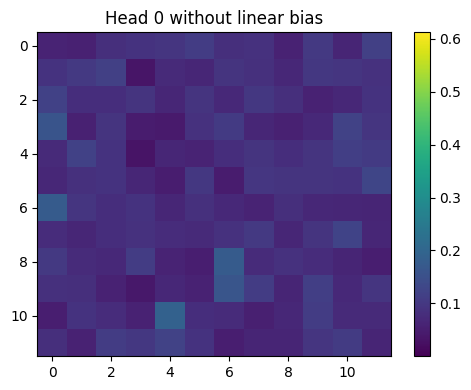

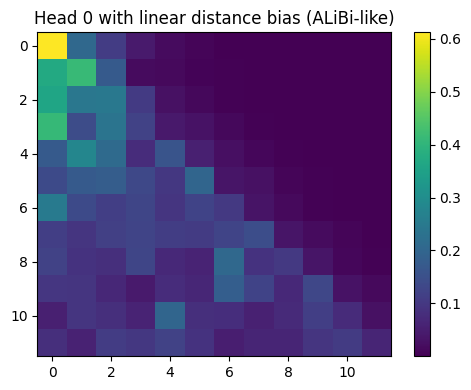

✓ ALiBi-like comparison plotted


In [69]:

# TESTS — compare attention with/without ALiBi-like bias (head 0)
B,L,d_model,H = 1, 12, 64, 2
X = torch.randn(B, L, d_model, device=device)
mhsa = MultiHeadSelfAttention(d_model, H).to(device)
Q = mhsa.WQ(X).view(B,L,H,mhsa.d_k).transpose(1,2)
K = mhsa.WK(X).view(B,L,H,mhsa.d_k).transpose(1,2)
scores = Q @ K.transpose(-2,-1) / math.sqrt(mhsa.d_k)
A0 = softmax_stable(scores, dim=-1)[0,0]

slopes = alibi_slopes(H)
bias = alibi_bias(L, slopes, device=device)
scores_b = scores + bias.unsqueeze(0)
A1 = softmax_stable(scores_b, dim=-1)[0,0]

vmin = torch.min(torch.stack([A0.min(), A1.min()])).item()
vmax = torch.max(torch.stack([A0.max(), A1.max()])).item()
show_attention(A0, title="Head 0 without linear bias", vmin=vmin, vmax=vmax)
show_attention(A1, title="Head 0 with linear distance bias (ALiBi-like)", vmin=vmin, vmax=vmax)
print("✓ ALiBi-like comparison plotted")


### 11) Cross-Attention (Encoder–Decoder)

In [70]:

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=64, num_heads=8, d_v=None, bias=False):
        super().__init__()
        assert d_model % num_heads == 0
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads
        self.d_v = self.d_k if d_v is None else d_v
        self.WQ = nn.Linear(d_model, num_heads*self.d_k, bias=bias)
        self.WK = nn.Linear(d_model, num_heads*self.d_k, bias=bias)
        self.WV = nn.Linear(d_model, num_heads*self.d_v, bias=bias)
        self.WO = nn.Linear(num_heads*self.d_v, d_model, bias=bias)

    def forward(self, Xq, Xkv, mask=None):  # mask [B,Lq,Lk] or None
        """TODO: implement cross-attention forward, returning (Z, A)."""
        B, Lq, _ = Xq.size()
        Lk = Xkv.size(1)
        Q = self.WQ(Xq).view(B, Lq, self.num_heads, self.d_k).transpose(1,2)  # (B, h, Lq, d_k)
        K = self.WK(Xkv).view(B, Lk, self.num_heads, self.d_k).transpose(1,2)  # (B, h, Lk, d_k)
        V = self.WV(Xkv).view(B, Lk, self.num_heads, self.d_v).transpose(1,2)  # (B, h, Lk, d_v)
        if mask is not None:
            mask = mask.unsqueeze(1)  # (B, 1, Lq, Lk)
        out, A = scaled_dot_product_attention(Q.reshape(B*self.num_heads, Lq, self.d_k),
                                             K.reshape(B*self.num_heads, Lk, self.d_k),
                                             V.reshape(B*self.num_heads, Lk, self.d_v),
                                             mask=mask.repeat_interleave(self.num_heads, dim=0) if mask is not None else None)
        out = out.view(B, self.num_heads, Lq, self.d_v).transpose(1,2).reshape(B, Lq, self.num_heads*self.d_v)  # (B, Lq, h*d_v)
        out = self.WO(out)  # (B, Lq, d_model)
        return out, A.view(B, self.num_heads, Lq, Lk)


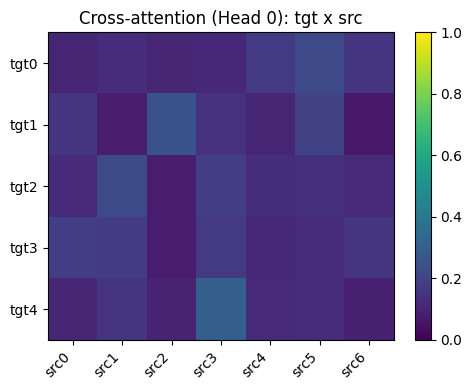

✓ Cross-attention basic test passed


In [71]:

# TESTS — cross-attention run + plot
B, L_src, L_tgt, d_model, H = 1, 7, 5, 64, 2
M = torch.randn(B, L_src, d_model, device=device)  # encoder memory
Y = torch.randn(B, L_tgt, d_model, device=device)  # decoder states
mha = MultiHeadAttention(d_model, H).to(device)
Z_cross, A_cross = mha(Y, M)
assert Z_cross.shape == (B, L_tgt, d_model) and A_cross.shape == (B, H, L_tgt, L_src)
show_attention(A_cross[0,0], xticks=[f"src{i}" for i in range(L_src)],
               yticks=[f"tgt{i}" for i in range(L_tgt)],
               title="Cross-attention (Head 0): tgt x src", vmin=0.0, vmax=1.0)
print("✓ Cross-attention basic test passed")


### 12) Time vs. Sequence Length (MHSA benchmark)

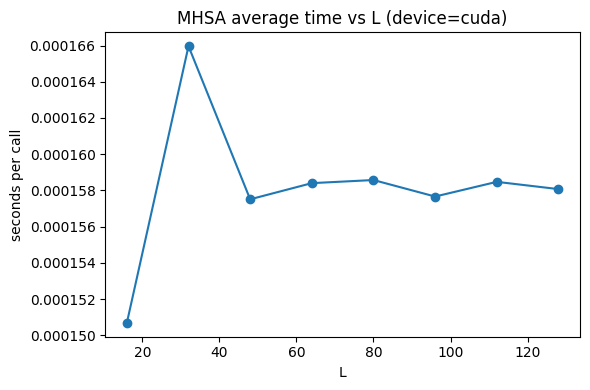

In [72]:

def bench_mhsa(L, d_model=128, heads=8, reps=50, device=device):
    """TODO: implement a simple runtime benchmark for MHSA."""
    B = 1
    X = torch.randn(B, L, d_model, device=device)
    mhsa = MultiHeadSelfAttention(d_model, heads).to(device)
    # Warm-up
    for _ in range(10):
        Z, A = mhsa(X)
    torch.cuda.synchronize() if device.type == 'cuda' else None
    start_time = time.time()
    for _ in range(reps):
        Z, A = mhsa(X)
    torch.cuda.synchronize() if device.type == 'cuda' else None
    end_time = time.time()
    avg_time = (end_time - start_time) / reps
    return avg_time

Ls = [16, 32, 48, 64, 80, 96, 112, 128]
times = [bench_mhsa(L) for L in Ls]
fig = plt.figure(figsize=(6,4)); plt.plot(Ls, times, marker='o')
plt.title(f"MHSA average time vs L (device={device})"); plt.xlabel("L"); plt.ylabel("seconds per call")
plt.tight_layout(); plt.show()


### 13) Extra demos — Scaling effect (large d_k) & Temperature sweep

Mean entropy without scaling: 0.4031
Mean entropy with scaling (scale=1.0): 0.4031


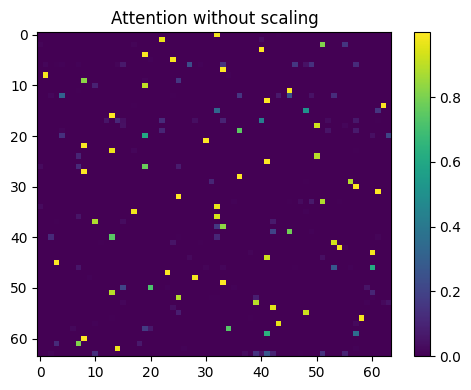

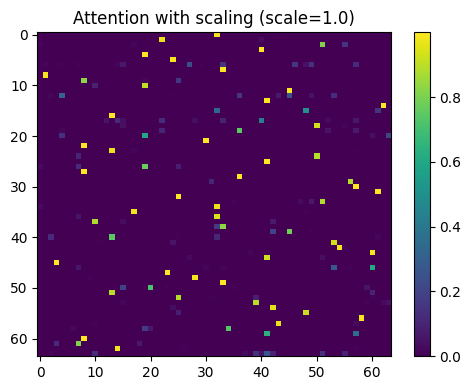

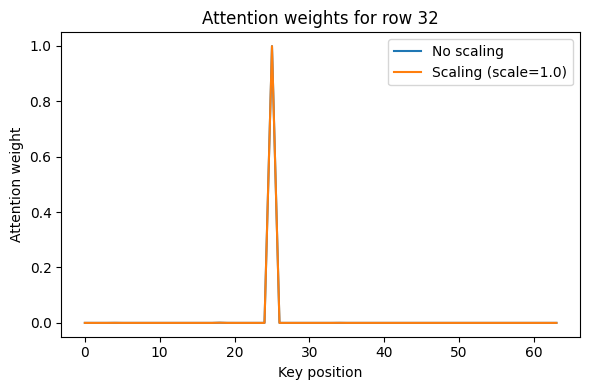

Temperature: 0.50, Mean Entropy: 0.2560
Temperature: 0.70, Mean Entropy: 0.3790
Temperature: 1.00, Mean Entropy: 0.5768
Temperature: 1.40, Mean Entropy: 0.8586
Temperature: 2.00, Mean Entropy: 1.3075
Temperature: 3.00, Mean Entropy: 2.0395


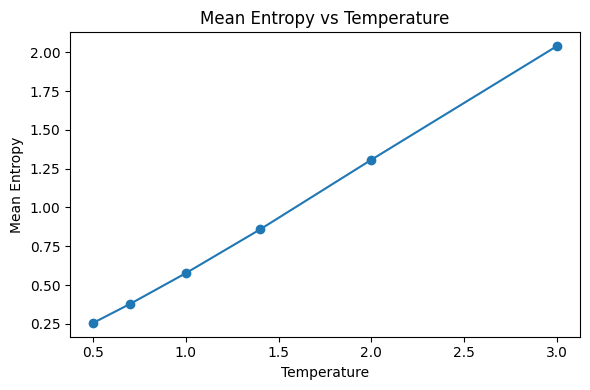

In [73]:

def demo_effect(L=64, d_k=64, scale_qk=1.0, device=device):
    """TODO: show entropy difference with/without scaling and plot one row of each."""
    Q = torch.randn(L, d_k, device=device)
    K = torch.randn(L, d_k, device=device)
    S = Q @ K.T
    S_scaled = S / scale_qk

    A_noscale = softmax_stable(S, dim=-1)
    A_scale = softmax_stable(S_scaled, dim=-1)

    ent_noscale = row_entropy(A_noscale, dim=-1)
    ent_scale = row_entropy(A_scale, dim=-1)

    mean_ent_noscale = ent_noscale.mean().item()
    mean_ent_scale = ent_scale.mean().item()

    print(f"Mean entropy without scaling: {mean_ent_noscale:.4f}")
    print(f"Mean entropy with scaling (scale={scale_qk}): {mean_ent_scale:.4f}")

    vmin = min(A_noscale.min().item(), A_scale.min().item())
    vmax = max(A_noscale.max().item(), A_scale.max().item())

    show_attention(A_noscale, title="Attention without scaling", vmin=vmin, vmax=vmax)
    show_attention(A_scale, title=f"Attention with scaling (scale={scale_qk})", vmin=vmin, vmax=vmax)

    row_idx = L // 2
    plt.figure(figsize=(6,4))
    plt.plot(A_noscale[row_idx].detach().cpu().numpy(), label="No scaling")
    plt.plot(A_scale[row_idx].detach().cpu().numpy(), label=f"Scaling (scale={scale_qk})")
    plt.title(f"Attention weights for row {row_idx}")
    plt.xlabel("Key position")
    plt.ylabel("Attention weight")
    plt.legend()
    plt.tight_layout()
    plt.show()

def sweep_temperature(S, Ts):
    """TODO: plot mean entropy vs temperature for a fixed logit matrix S."""
    entropies = []
    for T in Ts:
        S_temp = S / T
        A_temp = softmax_stable(S_temp, dim=-1)
        ent_temp = row_entropy(A_temp, dim=-1)
        mean_ent_temp = ent_temp.mean().item()
        entropies.append(mean_ent_temp)
        print(f"Temperature: {T:.2f}, Mean Entropy: {mean_ent_temp:.4f}")

    plt.figure(figsize=(6,4))
    plt.plot(Ts, entropies, marker='o')
    plt.title("Mean Entropy vs Temperature")
    plt.xlabel("Temperature")
    plt.ylabel("Mean Entropy")
    plt.tight_layout()
    plt.show()

# Example usage (uncomment after implementing):
demo_effect(L=64, d_k=64, scale_qk=1.0, device=device)
# demo_effect(L=64, d_k=64, scale_qk=3.0, device=device)
L, d_k = 64, 64
Q = torch.randn(L, d_k, device=device); K = torch.randn(L, d_k, device=device)
S = Q @ K.T
sweep_temperature(S, Ts=[0.5, 0.7, 1.0, 1.4, 2.0, 3.0])
